In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('../data/creditcard.csv')

# Basic info
print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (284807, 31)

First 5 rows:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
# Check missing values and duplicates
print("Missing values:")
print(df.isnull().sum().sum())

print(f"\nDuplicate rows: {df.duplicated().sum()}")

print("\nClass distribution:")
print(df['Class'].value_counts())
print(f"\nFraud percentage: {df['Class'].mean() * 100:.4f}%")

Missing values:
0

Duplicate rows: 1081

Class distribution:
Class
0    284315
1       492
Name: count, dtype: int64

Fraud percentage: 0.1727%


In [3]:
# Remove duplicates
df = df.drop_duplicates()
print(f"Shape after removing duplicates: {df.shape}")

# Check Amount and Time stats (these need scaling)
print("\nAmount statistics:")
print(df['Amount'].describe())

print("\nTime statistics:")
print(df['Time'].describe())

Shape after removing duplicates: (283726, 31)

Amount statistics:
count    283726.000000
mean         88.472687
std         250.399437
min           0.000000
25%           5.600000
50%          22.000000
75%          77.510000
max       25691.160000
Name: Amount, dtype: float64

Time statistics:
count    283726.000000
mean      94811.077600
std       47481.047891
min           0.000000
25%       54204.750000
50%       84692.500000
75%      139298.000000
max      172792.000000
Name: Time, dtype: float64


In [4]:
# Scale Amount and Time
from sklearn.preprocessing import StandardScaler

scaler_amount = StandardScaler()
scaler_time = StandardScaler()

df['Amount'] = scaler_amount.fit_transform(df[['Amount']])
df['Time'] = scaler_time.fit_transform(df[['Time']])

print("After scaling:")
print("\nAmount statistics:")
print(df['Amount'].describe())

print("\nTime statistics:")
print(df['Time'].describe())

After scaling:

Amount statistics:
count    2.837260e+05
mean    -8.013847e-19
std      1.000002e+00
min     -3.533268e-01
25%     -3.309625e-01
50%     -2.654671e-01
75%     -4.378088e-02
max      1.022476e+02
Name: Amount, dtype: float64

Time statistics:
count    2.837260e+05
mean     1.538659e-16
std      1.000002e+00
min     -1.996823e+00
25%     -8.552128e-01
50%     -2.131081e-01
75%      9.369423e-01
max      1.642362e+00
Name: Time, dtype: float64


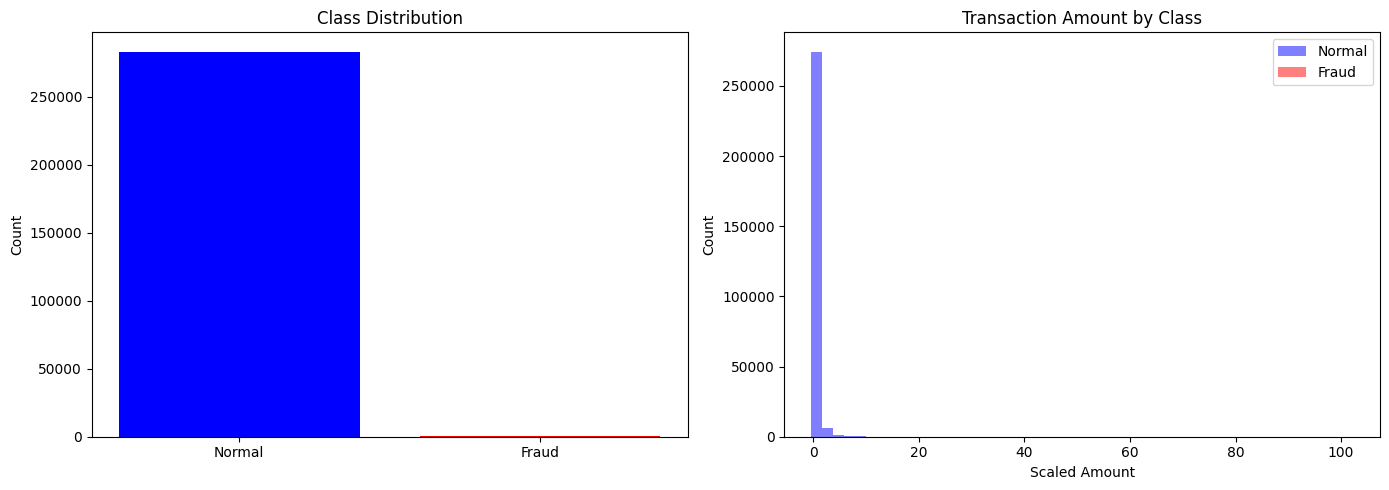

In [5]:
# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
axes[0].bar(['Normal', 'Fraud'], df['Class'].value_counts().values, color=['blue', 'red'])
axes[0].set_title('Class Distribution')
axes[0].set_ylabel('Count')

# Amount distribution by class
normal_amounts = df[df['Class'] == 0]['Amount']
fraud_amounts = df[df['Class'] == 1]['Amount']
axes[1].hist(normal_amounts, bins=50, alpha=0.5, label='Normal', color='blue')
axes[1].hist(fraud_amounts, bins=50, alpha=0.5, label='Fraud', color='red')
axes[1].set_title('Transaction Amount by Class')
axes[1].set_xlabel('Scaled Amount')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

In [6]:
# Save cleaned data
df.to_csv('../data/creditcard_cleaned.csv', index=False)
print("Cleaned data saved!")
print(f"Final shape: {df.shape}")
print(f"Normal: {(df['Class']==0).sum()}")
print(f"Fraud: {(df['Class']==1).sum()}")

Cleaned data saved!
Final shape: (283726, 31)
Normal: 283253
Fraud: 473


In [7]:
df.to_csv('../data/creditcard_cleaned.csv', index=False)
print("Saved!")

Saved!
